In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds

import matplotlib.pyplot as plt

In [24]:
(train_ds, val_ds, test_ds), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True, 
    with_info=True
)

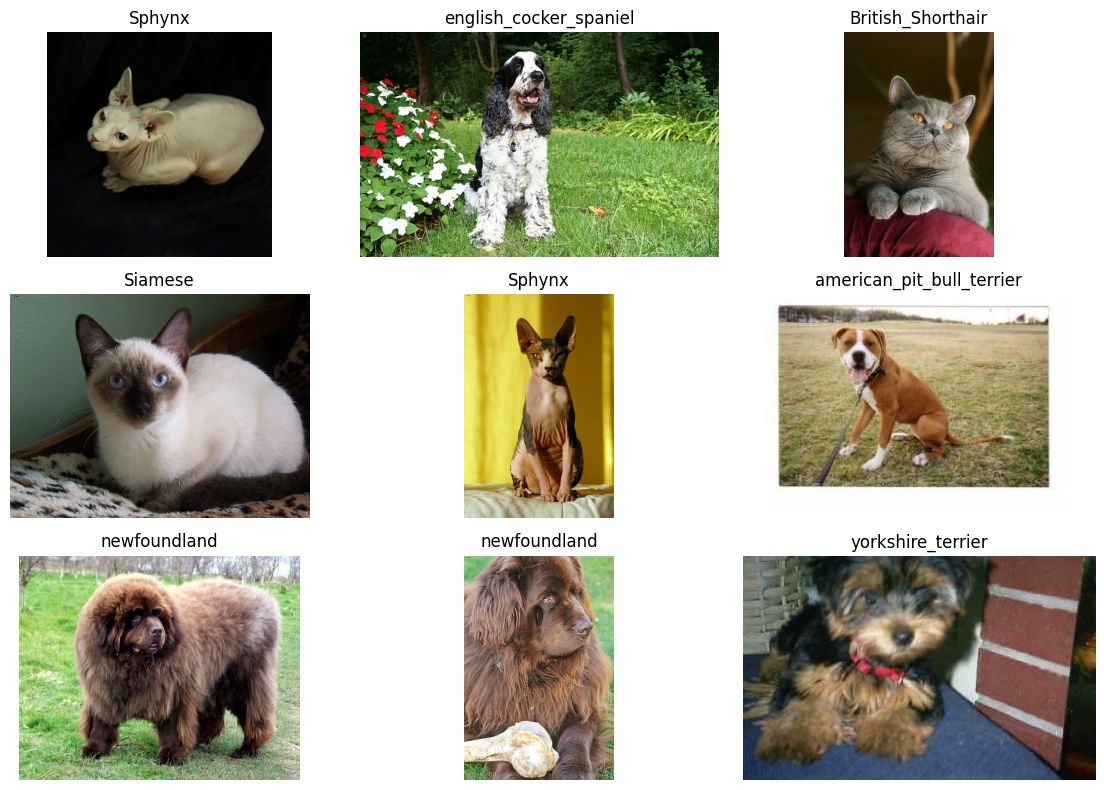

In [25]:
NUM_CLASSES = info.features['label'].num_classes
IMG_SIZE = 224

label_names = info.features["label"].names

plt.figure(figsize=(12, 8))

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i + 1)

    plt.imshow(image.numpy())
    plt.title(label_names[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v3.preprocess_input(image)
    
    return image, label

In [27]:
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

base_model = tf.keras.applications.MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False 

In [28]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(train_ds, validation_data=val_ds, epochs=8)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8940 - val_loss: 0.3686
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8940 - val_loss: 0.3635
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8967 - val_loss: 0.3617
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8995 - val_loss: 0.3617
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9008 - val_loss: 0.3622
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9022 - val_loss: 0.3626
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9022 - val_loss: 0.3636
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9

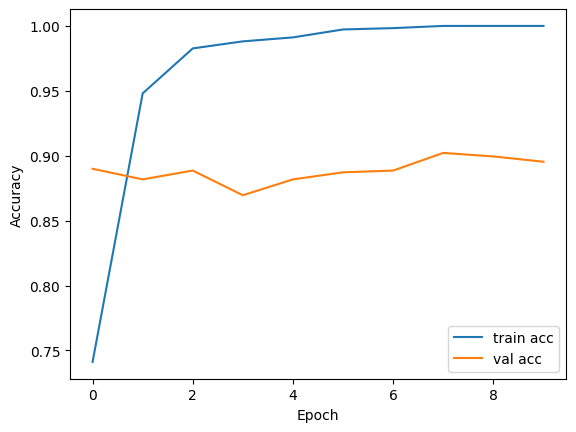

In [30]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
model.save("MobileNetV3_model_tf.keras")